<a href="https://colab.research.google.com/github/SCSVEL/learn-testing-ai_llm_models/blob/main/Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deepchecks pandas numpy==1.26.4

# Uninstall current NumPy (likely 2.x) and install a compatible version (1.x)
# !pip uninstall -y numpy
# !pip install numpy==1.26.4

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
import pandas as pd


loan_data = pd.read_csv("/content/sample_data/sample_loan_data.csv")

from sklearn.model_selection import train_test_split
from deepchecks.tabular import Dataset

label_col = 'not.fully.paid'
deep_loan_data = Dataset(loan_data, label=label_col, cat_features=["purpose"])

# Train test split
df_train, df_test = train_test_split(loan_data, stratify=loan_data[label_col], random_state=0)

# Encode the 'purpose' column
label_encoder = LabelEncoder()
df_train['purpose'] = label_encoder.fit_transform(df_train['purpose'])
df_test['purpose'] = label_encoder.fit_transform(df_test['purpose'])

# Define models
model_1 = LogisticRegression(random_state=1, max_iter=10000)
model_2 = RandomForestClassifier(n_estimators=50, random_state=1)
model_3 = GaussianNB()

# Create the VotingClassifier
clf_model = VotingClassifier(
    estimators=[('lr', model_1), ('rf', model_2), ('svc', model_3)],
    voting='soft'
)

# Train the model
clf_model.fit(df_train.drop(label_col, axis=1), df_train[label_col])


# Run the test suites
from deepchecks.tabular.suites import model_evaluation

deep_train = Dataset(df_train, label=label_col, cat_features=[])
deep_test =  Dataset(df_test,  label=label_col, cat_features=[])

evaluation_suite = model_evaluation()
suite_result = evaluation_suite.run(deep_train, deep_test, clf_model)
# suite_result.show_in_iframe()



deepchecks - WARNING - Could not find built-in feature importance on the model, using permutation feature importance calculation instead
deepchecks - INFO - Calculating permutation feature importance. Expected to finish in 5 seconds
INFO:deepchecks:Calculating permutation feature importance. Expected to finish in 5 seconds


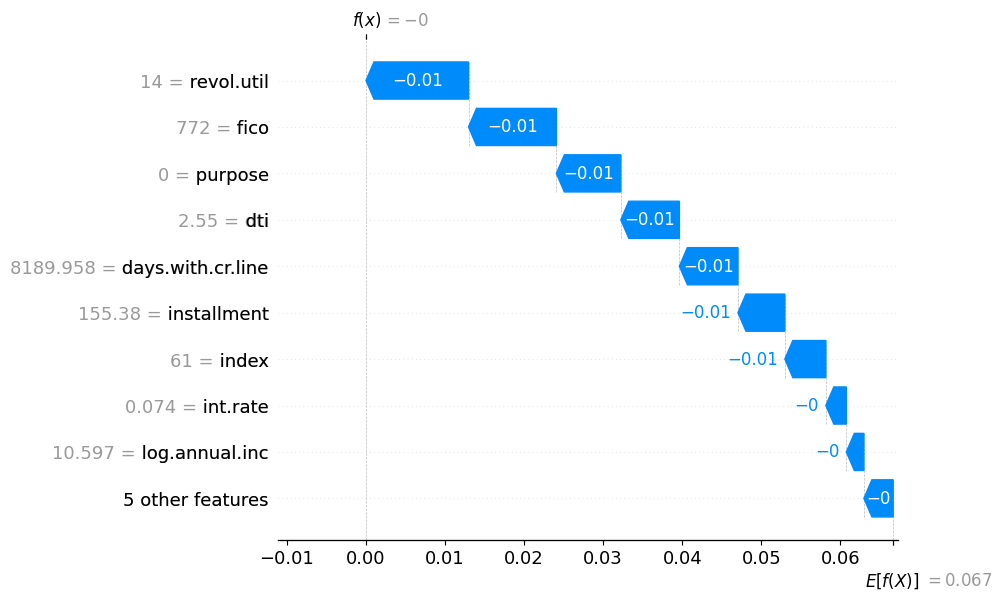

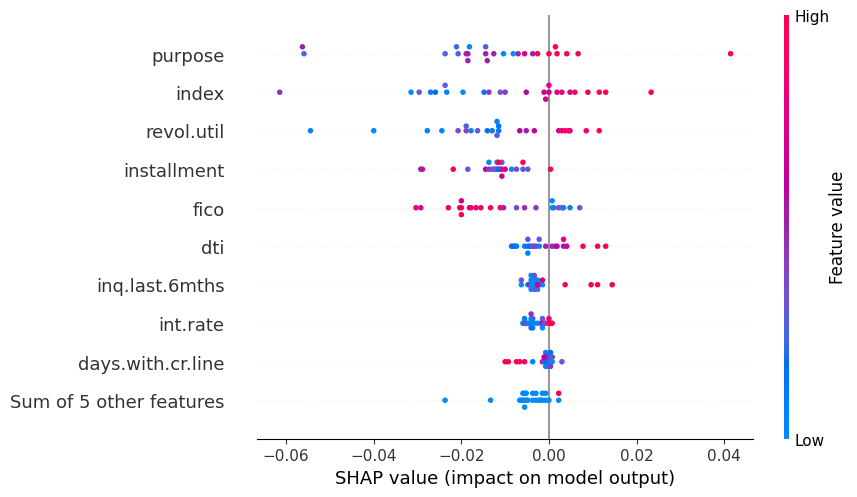

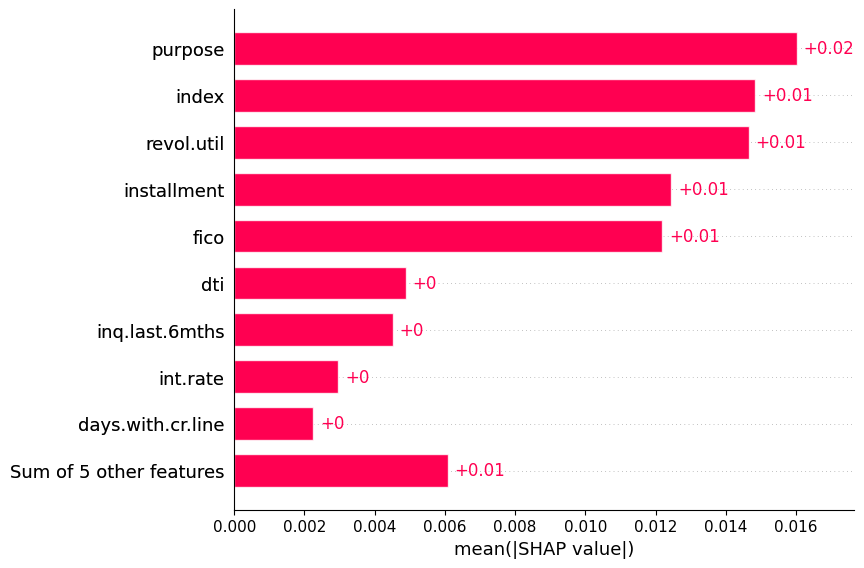

In [4]:
# Explainability check

# !pip install shap
import shap

explainer = shap.Explainer(clf_model.predict, df_train.drop(label_col, axis=1))
shap_values = explainer(df_test.drop(label_col, axis=1))
shap.plots.waterfall(shap_values[0])
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)

In [ ]:
import numpy as np

a = np.array([[1, 2],
              [3, 4],
              ["a", "0"]], dtype=object) # Initialize as object to allow mixed types gracefully

# Create a temporary numeric array, coercing non-numeric values to NaN
temp_a = np.empty(a.shape, dtype=float)
for r in range(a.shape[0]):
    for c in range(a.shape[1]):
        try:
            temp_a[r, c] = float(a[r, c])
        except ValueError:
            temp_a[r, c] = np.nan

# Now np.isnan can be applied to temp_a to create the mask
a = a[np.logical_not(np.isnan(temp_a)).any(axis=1)]
print(a)
a = a[np.logical_not([1, 2] == a).any(axis=1)]
print(a)
